# **House Prices - Advanced Regression Techniques**

---

prediction-project

---

##Project Overview
  The goal of this project is to predict house sale prices using different property characteristics (quality, area, year built, etc).

  This is a supervised machine learning regression task based on the House Prices - Advanced Regression Techniques dataset.

##Objectives


*   Perform exploratory data analysis (EDA)

*   Handle missing values and outliers

*   Engineer meaningful features
*   Create and compare multiple regresiion models


*    Evaluate model performance using RMSE


*   Interpret vital features affecting house sale prices



##Business understanding

Accurate prediction of house prices can help:


*   Real estate agencies estimate property value
*   Buyers who are in search of a bargain prices of houses


*   Sallers set competitive prices
*   Investors analyze market opportunities

The target variable is:
- `SalePrice`










In [55]:
# Data manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_selection import mutual_info_regression
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import root_mean_squared_error

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 0

## Dataset Loading

In this section, the training dataset is loaded and  its basic structure is inspected.

In [3]:
df=pd.read_csv('/content/sample_data/train.csv')
print(df.shape)
df.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## Initial Data Inspection

 Examined:
- dataset dimensions
- feature types
- missing values
- encoding
- summary statistics

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [5]:
df.describe()

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


In [6]:
missing=df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing.head(20)

,0
PoolQC,1453
MiscFeature,1406
Alley,1369
Fence,1179
MasVnrType,872
FireplaceQu,690
LotFrontage,259
GarageQual,81
GarageFinish,81
GarageType,81


Several features contain missing values.
Further analysis is required to determine whether these values should be imputed or removed.

Several missing-value-heavy features actually indicate the absence of a property characteristic rather than missing information.

To capture this signal, binary features such as `HasGarage` and `HasPool` were created. And feature like 'LuxuryScore' shows overall sum of that features.

In [7]:
#adding some features
df["HasGarage"] = df["GarageType"].notnull().astype(int)
df["HasPool"] = df["PoolQC"].notnull().astype(int)
df["HasFence"] = df["Fence"].notnull().astype(int)
df["HasAlley"] = df["Alley"].notnull().astype(int)

df["LuxuryScore"] = ( df["HasPool"] + df["HasGarage"] + df["HasFence"])


In [8]:
#seeing whether these features are needed
new_features=["HasGarage","HasPool","HasFence","HasAlley"]
df[new_features+["SalePrice"]].corr()


,HasGarage,HasPool,HasFence,HasAlley,SalePrice
HasGarage,1.000000,0.016822,-0.003114,-0.048905,0.236832
HasPool,0.016822,1.000000,0.117023,-0.017895,0.093708
HasFence,-0.003114,0.117023,1.000000,0.003490,-0.172184
HasAlley,-0.048905,-0.017895,0.003490,1.000000,-0.123611
SalePrice,0.236832,0.093708,-0.172184,-0.123611,1.000000


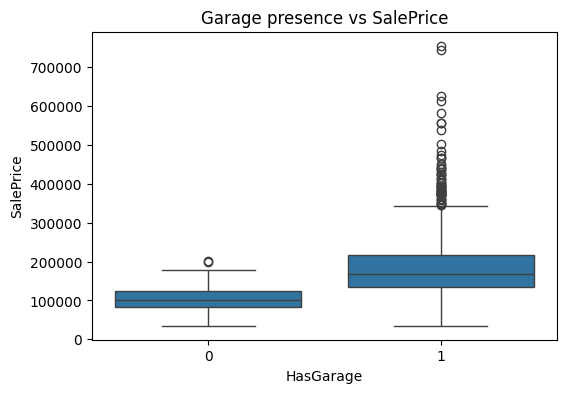

In [10]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["HasGarage"], y=df["SalePrice"])
plt.title("Garage presence vs SalePrice")
plt.show()

Properties with garages tend to have higher sale prices, indicating that garage availability is an important feature.

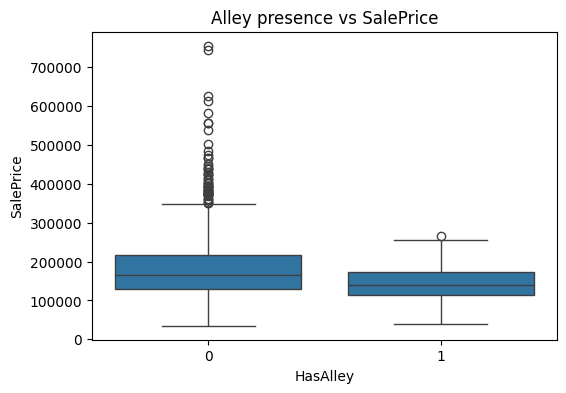

In [11]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["HasAlley"], y=df["SalePrice"])
plt.title("Alley presence vs SalePrice")
plt.show()

Properties with alleys tend to have lower sale prices, indicating that alley availability is an important feature.

In [17]:
df[['LuxuryScore']+["SalePrice"]].corr()

,LuxuryScore,SalePrice
LuxuryScore,1.000000,-0.015375
SalePrice,-0.015375,1.000000


The engineered feature showed weak correlation with the target variable and was therefore excluded from further modeling.

continuing with missing values:

In [12]:
num_features=df.select_dtypes(include=["int64","float64"])
skewness=num_features.skew().sort_values(ascending=False)
skewness.head(20)

,0
MiscVal,24.476794
PoolArea,14.828374
HasPool,14.352680
LotArea,12.207688
3SsnPorch,10.304342
LowQualFinSF,9.011341
KitchenAbvGr,4.488397
BsmtFinSF2,4.255261
ScreenPorch,4.122214
BsmtHalfBath,4.103403


Many numerical features exhibit strong right-skewness.

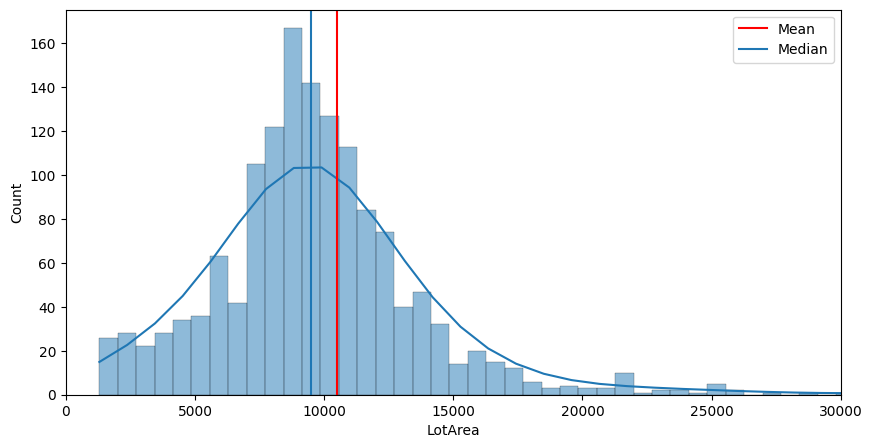

In [16]:
plt.figure(figsize=(10,5))
sns.histplot(df['LotArea'],kde=True)
plt.axvline(df['LotArea'].mean(),color="red",label="Mean")
plt.axvline(df['LotArea'].median(),label="Median")
plt.xlim(0, 30000)
plt.legend()
plt.show()

The distribution of `LotArea` is right-skewed with several extreme values.

The mean is shifted to the right a little due to outliers, while the median remains closer to the central mass of the data.

This supports the use of median imputation for skewed numerical features.

In [26]:
num_cols=num_features.columns
for col in num_cols:
  df[col]=df[col].fillna(df[col].median())

In [24]:
cat_cols=df.select_dtypes(include=["object"]).columns
for col in cat_cols:
  df[col]=df[col].fillna("None")

In [27]:
df.isnull().sum().sum()
#checking

np.int64(0)

Many numerical features exhibit strong right-skewness: connected to area of all house, total bathrooms,porch area,house age,remodeled age,total rooms

In [29]:
df["TotalSF"] = (
    df["TotalBsmtSF"] +
    df["1stFlrSF"] +
    df["2ndFlrSF"]
)

df["TotalBathrooms"] = (
    df["FullBath"] +
    (0.5 * df["HalfBath"]) +
    df["BsmtFullBath"] +
    (0.5 * df["BsmtHalfBath"])
)

df["TotalPorchSF"] = (
    df["OpenPorchSF"] +
    df["3SsnPorch"] +
    df["EnclosedPorch"] +
    df["ScreenPorch"] +
    df["WoodDeckSF"]
)
df["HouseAge"] = (
    df["YrSold"] -
    df["YearBuilt"]
)
df["RemodelAge"] = (
    df["YrSold"] -
    df["YearRemodAdd"]
)
df["TotalRooms"] = (
    df["TotRmsAbvGrd"] +
    df["BedroomAbvGr"]
)

In [30]:
new_features = [
    "TotalSF",
    "TotalBathrooms",
    "TotalPorchSF",
    "HouseAge",
    "RemodelAge",
    "TotalRooms"
]

df[new_features + ["SalePrice"]].corr()

,TotalSF,TotalBathrooms,TotalPorchSF,HouseAge,RemodelAge,TotalRooms,SalePrice
TotalSF,1.000000,0.604324,0.397428,-0.347892,-0.344859,0.611876,0.782260
TotalBathrooms,0.604324,1.000000,0.313911,-0.522595,-0.442525,0.416053,0.631731
TotalPorchSF,0.397428,0.313911,1.000000,-0.096563,-0.179581,0.220085,0.390993
HouseAge,-0.347892,-0.522595,-0.096563,1.000000,0.594195,-0.044864,-0.523350
RemodelAge,-0.344859,-0.442525,-0.179581,0.594195,1.000000,-0.125785,-0.509079
TotalRooms,0.611876,0.416053,0.220085,-0.044864,-0.125785,1.000000,0.444828
SalePrice,0.782260,0.631731,0.390993,-0.523350,-0.509079,0.444828,1.000000


Added features showed high correlation results, so that they worth being included.


In [33]:
#encoding
df=pd.get_dummies(df,drop_first=True)


In the following cells skewness of SalePrice is checked again. As I have mentioned before, it is skewed to the right (>1 as well).

So I will aplly log-transform to standartize extreme values, to easify regresssion in the long run

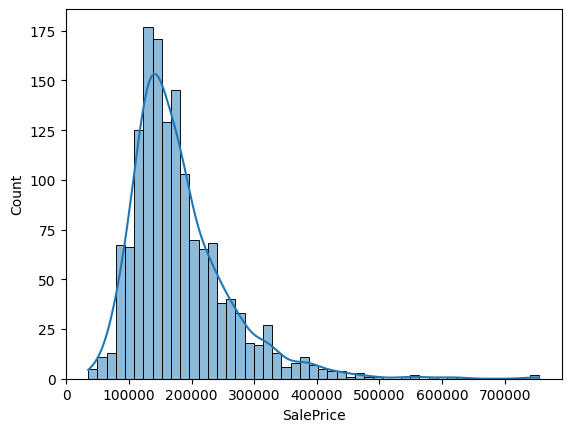

In [38]:
sns.histplot(df["SalePrice"], kde=True)
plt.show()

In [39]:
df["SalePrice"].skew()


np.float64(1.8828757597682129)

In [40]:
df["SalePrice"] = np.log1p(df["SalePrice"])

##Train-validation split:
Train-Validation Split for training and checking our future models.

In [41]:
X=df.drop("SalePrice",axis=1)
y=df["SalePrice"]

In [42]:
X_train,X_valid,y_train,y_valid=train_test_split(X,y, test_size=0.2,random_state=RANDOM_STATE)

## Evaluation Metric

The model was evaluated using Root Mean Squared Error (RMSE).

RMSE measures the average magnitude of prediction errors and penalizes large errors more heavily due to squaring.

This metric is particularly suitable for house price prediction because large pricing errors are more significant than small ones.

##Linear Regression model

A Linear Regression model was used as the baseline approach for the regression task.

Linear Regression is simple, interpretable, and provides a useful reference point for comparing more advanced machine learning models.

In [43]:
lr=LinearRegression()
lr.fit(X_train,y_train)
preds_lr=lr.predict(X_valid)
rmse_lr=root_mean_squared_error(y_valid,preds_lr)
print(rmse_lr)

0.23744073844844493


The baseline Linear Regression model achieved an RMSE of 0.23744073844844493 on the validation set.

The result indicates that the model captures some general relationships in the data, but performance remains limited due to nonlinear patterns and complex feature interactions within the dataset.

##Random Forest Regressor model

This model performs well on structured tabular data and can capture nonlinear relationships between features. Also, it has many interaction and categorial effects.

In [44]:
rf = RandomForestRegressor(random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
preds_rf = rf.predict(X_valid)
rmse_rf = root_mean_squared_error(y_valid, preds_rf)
print(rmse_rf)

0.14578464630807886


In [45]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest"],
    "RMSE": [
        rmse_lr,
        rmse_rf]
})

results

,Model,RMSE
0,Linear Regression,0.237441
1,Random Forest,0.145785


## Model Comparison: Linear vs Random Forest Regression

Random Forest achieved a lower RMSE compared to the baseline Linear Regression model.

This improvement suggests that nonlinear tree-based models are better suited for capturing complex relationships within the housing dataset.

##Feature Importance
Feature importance reflects how strongly each feature contributes to model predictions.

In [46]:
importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,OverallQual,0.373295
42,TotalSF,0.367269
207,CentralAir_Y,0.022988
43,TotalBathrooms,0.019636
16,GrLivArea,0.013927
27,GarageArea,0.012949
3,LotArea,0.011101
5,OverallCond,0.009975
45,HouseAge,0.009693
26,GarageCars,0.009240


In [49]:
importance.tail(10)

,Feature,Importance
128,RoofMatl_WdShake,3.397171e-09
133,Exterior1st_CBlock,2.542851e-09
61,Utilities_NoSeWa,3.585955e-10
105,Condition2_RRAn,0.000000e+00
106,Condition2_RRNn,0.000000e+00
259,SaleType_CWD,0.000000e+00
258,MiscFeature_TenC,0.000000e+00
104,Condition2_RRAe,0.000000e+00
144,Exterior2nd_AsphShn,0.000000e+00
220,Functional_Sev,0.000000e+00


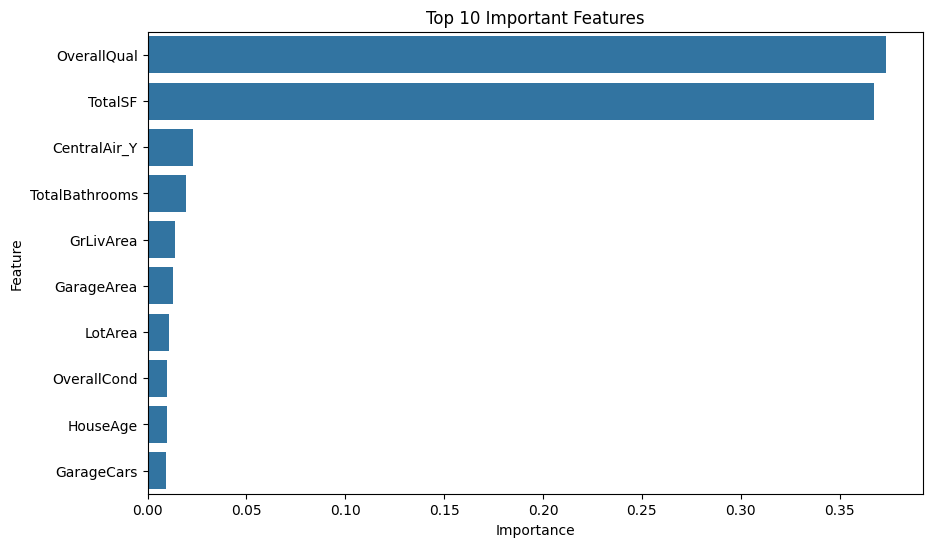

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Important Features")

plt.show()


Above there are top 10 features. The feature which  most affected the dataset is `OverallQual`. Also, `TotalSF` show great impact on the result.

What's more, there are about 7 features whci show total uselessness to our result.

##MI score
Mutual Information score is useful for finding some more important features.

In [51]:
mi_scores = mutual_info_regression(
    X_train,
    y_train,
    random_state=RANDOM_STATE
)

mi_scores = pd.Series(
    mi_scores,
    index=X_train.columns
)

mi_scores = mi_scores.sort_values(
    ascending=False
)

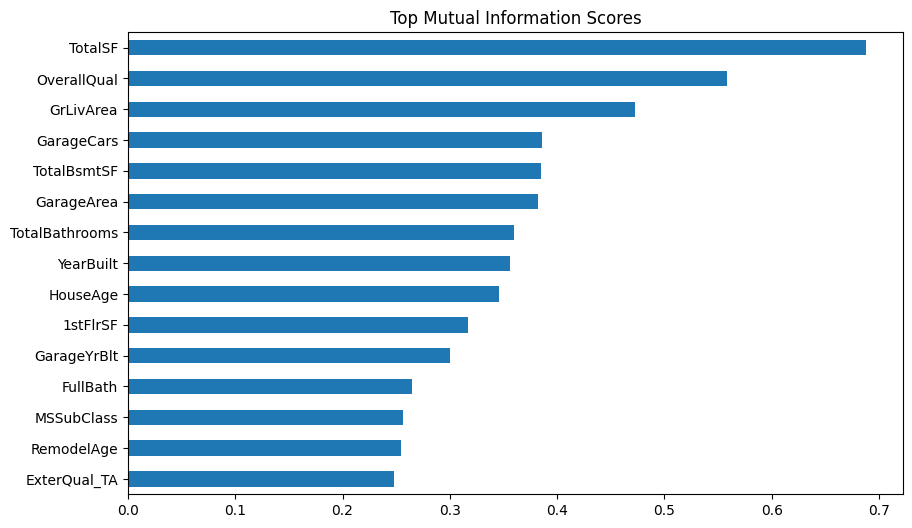

In [52]:
plt.figure(figsize=(10, 6))

mi_scores.head(15).sort_values().plot.barh()

plt.title("Top Mutual Information Scores")

plt.show()

`TotalSF` achieved the highest Mutual Information score, indicating a strong dependency with the target variable. Next goes `OverallQual` which had top 1 in feature impotance section.

`GrLivArea` shows also high MI score, whereas in feature importance it is only top 5.



##Cross Validation
This step will show whether our model might be over- or under- fitting.

So it helps us to estimate our model across different data splits.

In [53]:
cv_scores = cross_val_score(
    rf,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse = -cv_scores.mean()

print(cv_rmse)

0.14413184510332777


Cross-validation confirmed that the Random Forest model achieved an RMSE of 0.14413184510332777 on the validation set, significantly outperforming the baseline Linear Regression model.

This improvement suggests that tree-based models are more effective at capturing nonlinear relationships and feature interactions within the housing dataset.

##GradientBoostingRegressor
While Random Forest builds independent trees in parallel and averages their results (bagging), Gradient Boostingbuilds trees sequentially. Each new tree corrects the errors of the previous ones. Boosting usually achieves higher accuracy but requires more careful tuning to avoid overfitting.

In [63]:
gbr = GradientBoostingRegressor(
    random_state=RANDOM_STATE)

gbr.fit(X_train, y_train)

preds_gbr = gbr.predict(X_valid)
rmse_gbr = root_mean_squared_error(
    y_valid,
    preds_gbr)

print(rmse_gbr)

0.13348022671545998


In [60]:
cv_scores_gbr = cross_val_score(
    gbr,
    X,
    y,
    cv=5,
    scoring="neg_root_mean_squared_error"
)

cv_rmse_gbr = -cv_scores_gbr.mean()

print(cv_rmse_gbr)

0.12597965376905057


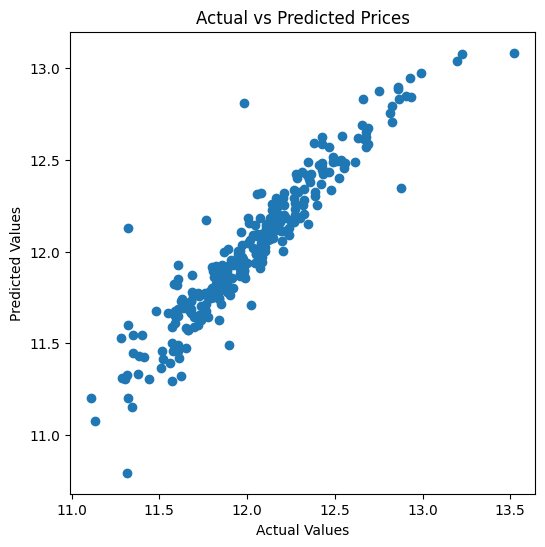

In [62]:
plt.figure(figsize=(6,6))

plt.scatter(
    y_valid,
    preds_gbr
)

plt.xlabel("Actual Values")

plt.ylabel("Predicted Values")

plt.title("Actual vs Predicted Prices")

plt.show()

Gradient Boosting achieved the best performance among the evaluated models.

This result suggests that boosting methods are highly effective for structured tabular datasets due to their ability to iteratively correct prediction errors.

## Limitations

The project uses relatively simple preprocessing and default model hyperparameters.

Further improvements could be achieved through:
- advanced hyperparameter tuning,
- ensemble methods,
- additional feature engineering,
- SHAP-based interpretability analysis.

##Conclusion

In [61]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"],
    "RMSE": [
        rmse_lr,
        rmse_rf,
        rmse_gbr]
})

results

,Model,RMSE
0,Linear Regression,0.237441
1,Random Forest,0.145785
2,Gradient Boosting,0.133480



In this project, several machine learning techniques were applied to predict house prices using the House Prices dataset.

The workflow included:
- exploratory data analysis,
- missing value handling,
- feature engineering,
- categorical encoding,
- model training and evaluation.

Several engineered features such as `TotalSF` and `TotalBathrooms` improved the representation of property characteristics and contributed to model performance.

A baseline Linear Regression model was first implemented to establish a reference point. However, due to nonlinear relationships within the dataset, tree-based models achieved significantly better results.

Among the evaluated models, Gradient Boosting achieved the best performance with the lowest RMSE score, outperforming both Linear Regression and Random Forest.

Feature importance analysis showed that variables related to overall quality, living area, and total square footage had the strongest impact on house prices.

Overall, this project demonstrated the importance of data preprocessing, feature engineering, and model selection in building effective machine learning solutions for structured tabular data.

Possible future improvements include:
- hyperparameter tuning,
- XGBoost or LightGBM models,
- advanced interpretability techniques such as SHAP values.